# 02. Сравнение моделей и эксперименты

Экспериментальный протокол (полный прогон: `python -m src.models.train`):

1. **Базовые модели** — LogisticRegression, RandomForest, GradientBoosting с параметрами из `configs/config.yaml`.
2. **Улучшенные модели** — тюнинг гиперпараметров через `GridSearchCV` (5-fold StratifiedKFold, scoring=ROC-AUC) + **MLP** как нейросетевой бейзлайн.
3. **Выбор лучшей модели** — по кросс-валидационному ROC-AUC на train (тест не участвует в выборе).
4. **Подбор порога классификации** — максимизация F2 на out-of-fold предсказаниях train.
5. Все прогоны логируются в **MLflow** (`mlruns/`, эксперимент `telco-churn`).

**Метрики:** ROC-AUC (основная), F1/F2, precision, recall (recall важнее: пропустить уходящего клиента дороже), accuracy — справочно.

In [1]:
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    fbeta_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

from src.data.load import load_clean
from src.data.preprocess import build_preprocessor, train_test_split_stratified
from src.models.train import build_pipeline, load_config

sns.set_theme(style='whitegrid')
FIG_DIR = PROJECT_ROOT / 'artifacts' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_clean(PROJECT_ROOT / 'data' / 'raw' / 'telco_churn.csv')
cfg = load_config()
x_train, x_test, y_train, y_test = train_test_split_stratified(df)
print('Train:', x_train.shape, 'Test:', x_test.shape)

Train: (5634, 19) Test: (1409, 19)


## 1. Сводная таблица всех экспериментов

Метрики берём из `artifacts/metrics.json` — результата полного прогона `python -m src.models.train`.

In [3]:
summary = json.loads((PROJECT_ROOT / 'artifacts' / 'metrics.json').read_text(encoding='utf-8'))

rows = []
for run_name, res in summary['results'].items():
    rows.append({
        'run': run_name,
        'cv_roc_auc': res.get('cv_roc_auc', np.nan),
        **res['test'],
    })
metrics_df = pd.DataFrame(rows).set_index('run')
metrics_df = metrics_df[['cv_roc_auc', 'roc_auc', 'f1', 'f2', 'precision', 'recall', 'accuracy']]
print('Лучшая модель по CV ROC-AUC:', summary['best_model'])
print('Подобранный порог:', summary['threshold']['threshold'])
metrics_df.round(4)

Лучшая модель по CV ROC-AUC: tuned_gradient_boosting
Подобранный порог: 0.14


,cv_roc_auc,roc_auc,f1,f2,precision,recall,accuracy
run,,,,,,,
baseline_logreg,NaN,0.8416,0.6136,0.7053,0.5043,0.7834,0.7381
baseline_random_forest,NaN,0.8341,0.6042,0.6292,0.5667,0.6471,0.7750
baseline_gradient_boosting,NaN,0.8347,0.5651,0.5311,0.6325,0.5107,0.7913
tuned_logreg,0.8462,0.8406,0.6149,0.7060,0.5060,0.7834,0.7395
tuned_random_forest,0.8473,0.8423,0.6321,0.7150,0.5298,0.7834,0.7580
tuned_gradient_boosting,0.8498,0.8455,0.5710,0.5297,0.6562,0.5053,0.7984
tuned_mlp,0.8436,0.8395,0.5290,0.4707,0.6667,0.4385,0.7928


## 2. ROC-кривые

Базовые модели обучаем заново (это быстро), лучшую тюнингованную загружаем из `artifacts/model.pkl`.

In [4]:
fitted = {}
for name, spec in cfg['models'].items():
    pipe = build_pipeline(name, spec.get('params', {}))
    pipe.fit(x_train, y_train)
    fitted[f'baseline_{name}'] = pipe

best_name = summary['best_model']
fitted[best_name] = joblib.load(PROJECT_ROOT / 'artifacts' / 'model.pkl')
print('Моделей для сравнения:', len(fitted))

Моделей для сравнения: 4


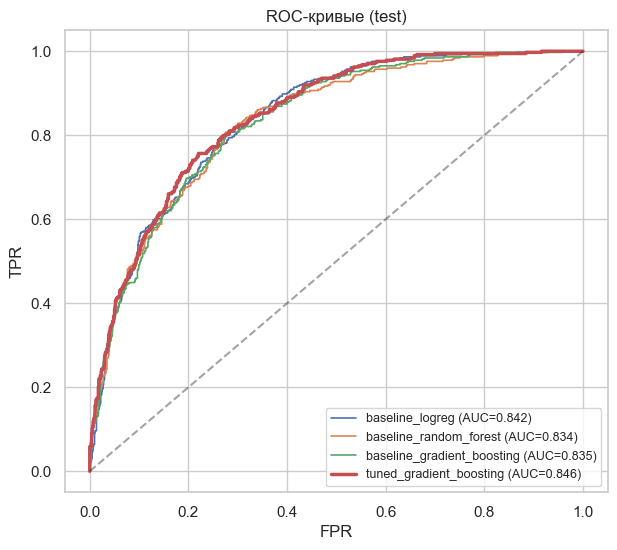

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    lw = 2.5 if name == best_name else 1.2
    ax.plot(fpr, tpr, lw=lw, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривые (test)')
ax.legend(loc='lower right', fontsize=9)
fig.savefig(FIG_DIR / 'fig_roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Подбор порога классификации

Порог подбирается **на out-of-fold предсказаниях train** (тест не участвует), максимизируя F2 — метрику, в которой recall весит больше precision. Бизнес-логика: пропущенный уходящий клиент (FN) дороже, чем лишняя кампания удержания (FP).

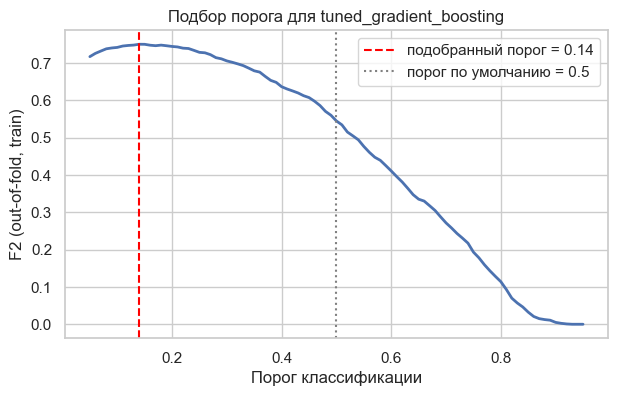

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(
    clone(fitted[best_name]), x_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

grid = np.arange(0.05, 0.951, 0.01)
f2_scores = [fbeta_score(y_train, oof_proba >= t, beta=2) for t in grid]
best_t = summary['threshold']['threshold']

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, f2_scores, lw=2)
ax.axvline(best_t, color='red', ls='--', label=f'подобранный порог = {best_t}')
ax.axvline(0.5, color='gray', ls=':', label='порог по умолчанию = 0.5')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F2 (out-of-fold, train)')
ax.set_title(f'Подбор порога для {best_name}')
ax.legend()
fig.savefig(FIG_DIR / 'fig_threshold_tuning.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Confusion matrix финальной модели

Сравниваем матрицы ошибок при пороге 0.5 и при подобранном пороге.

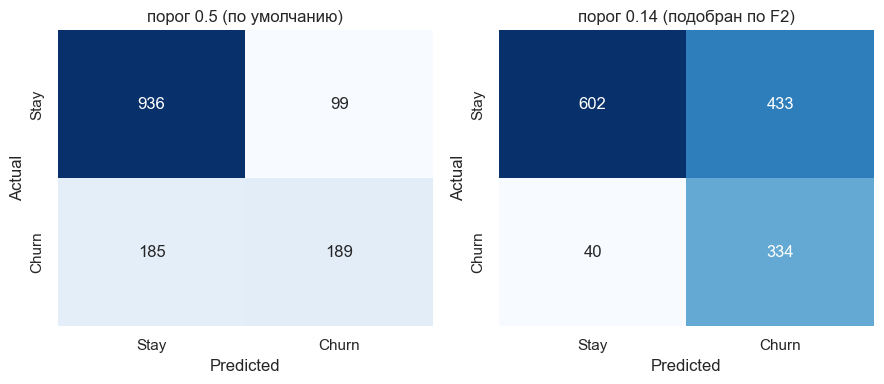

              precision    recall  f1-score   support

        Stay       0.94      0.58      0.72      1035
       Churn       0.44      0.89      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.80      0.66      0.68      1409



In [7]:
proba_test = fitted[best_name].predict_proba(x_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, t, title in [
    (axes[0], 0.5, 'порог 0.5 (по умолчанию)'),
    (axes[1], best_t, f'порог {best_t} (подобран по F2)'),
]:
    cm = confusion_matrix(y_test, proba_test >= t)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

print(classification_report(y_test, proba_test >= best_t, target_names=['Stay', 'Churn']))

## Выводы

1. **Тюнинг гиперпараметров поднял качество всех моделей.** Лучшей по CV ROC-AUC стала
   **GradientBoosting (learning_rate=0.05, max_depth=2, n_estimators=200)**: CV ROC-AUC ≈ 0.850, test ≈ 0.846.
2. **MLP (нейросетевой бейзлайн)** показал ROC-AUC ≈ 0.840 — на уровне линейной модели, но не лучше
   градиентного бустинга. Для табличных данных такого объёма (7 тыс. строк) это ожидаемо: преимущества
   нейросетей не реализуются, а стоимость (время обучения, подбор архитектуры) выше.
3. **Подбор порога — ключевое улучшение для бизнес-метрики.** При пороге 0.5 GradientBoosting ловил лишь ~51%
   уходящих клиентов; при подобранном по F2 пороге recall на тесте вырос до ~0.89 (точность ~0.44 — приемлемая
   цена, так как пропуск уходящего клиента дороже лишней кампании удержания).
4. Все эксперименты воспроизводимы (`random_state=42`) и залогированы в MLflow (`mlruns/`).

**Финальная конфигурация:** GradientBoosting (тюнинг по сетке) + порог 0.14.
Сохранена в `artifacts/model.pkl` + `artifacts/threshold.json` и используется сервисом в `/predict`.